# $-\Delta u + u = f$ on a square with a hole, $P_2$ elements

We solve

$$-\Delta u + u = f \quad \text{in } \Omega, \qquad u = g \ \text{ on the outer boundary}, \qquad \frac{\partial u}{\partial n} = 0 \ \text{ on the hole},$$

where $\Omega$ is the square $(-1, 1)^2$ with a circular hole of radius $r_0 = 0.4$ at the origin. As exact solution we take the potential of the flow past a cylinder,

$$u(x, y) = x\left(1 + \frac{r_0^2}{x^2 + y^2}\right).$$

It is harmonic, $\Delta u = 0$, so $f = u$, and its normal derivative vanishes on the circle $x^2 + y^2 = r_0^2$. The Dirichlet data $g$ on the outer boundary are the values of $u$ there.

Multiplying by a test function $v$ that vanishes on the outer boundary and integrating by parts gives

$$\int_\Omega \left(\nabla u \cdot \nabla v + u\,v\right) dx = \int_\Omega f\,v\,dx + \int_{\text{hole}} \frac{\partial u}{\partial n}\,v\,ds.$$

The last term is zero because $\partial u / \partial n = 0$ on the hole. So the condition on the hole is natural. Nothing is imposed there, and $v$ is free on the hole.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import femd as fd
from femd import dot, grad, dx

The mesh. `fd.triangulate` meshes the square with the circle, given by 32 points, as a hole. The outer boundary gets the marker 1 and the hole the marker 2. `max_edge` bounds the length of the edges and `min_angle` is the smallest angle in degrees.

1792 triangles, side markers [1 2]


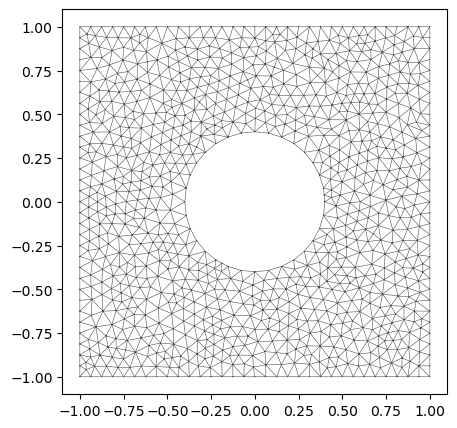

In [2]:
r0 = 0.4
square = [(-1, -1), (1, -1), (1, 1), (-1, 1)]
hole = fd.circle(0, 0, r0, 32)
m = fd.triangulate(square, holes=[hole], max_edge=0.1, min_angle=30, smooth=100, interior_vertex=True)
print(len(m.triangles), "triangles, side markers", np.unique(m.segment_markers))

fig, ax = plt.subplots(figsize=(5, 5))
m.plot(ax)
ax.set_aspect("equal")
plt.show()

Continuous $P_2$ elements. `dirichlet={1: g}` builds the Dirichlet condition with its data into the space on the sides with marker 1, the outer square. The hole, marker 2, is not named, so nothing is built in there and it is free.

In [3]:
def exact(x, y):
    return x * (1 + r0**2 / (x**2 + y**2))

V = fd.LagrangeSpace(m, 2, dirichlet={1: exact})
u, v = fd.TrialFunction(V), fd.TestFunction(V)
print("unknowns:", V.dim)

unknowns: 3490


The bilinear form, the right-hand side, and the solve, which takes the boundary values from the space.

In [4]:
uex = fd.x * (1 + r0**2 / (fd.x**2 + fd.y**2))      # the exact solution as an expression in x and y
f = uex                                             # -Laplace(u) + u = u, since u is harmonic

a = (dot(grad(u), grad(v)) + u * v) * dx
L = f * v * dx

uh = fd.solve(a, L)

We compare with the exact solution, using the maximum error at the vertices of the mesh and the errors in $L^2$ and in the $H^1$ seminorm, integrated by quadrature on each triangle. In the plot the contour lines of $u_h$ meet the hole at right angles, which is the condition $\partial u / \partial n = 0$.

max error at the vertices: 0.001827137475226337
L2 error: 0.000903549273457409
H1 error: 0.00653396306012702


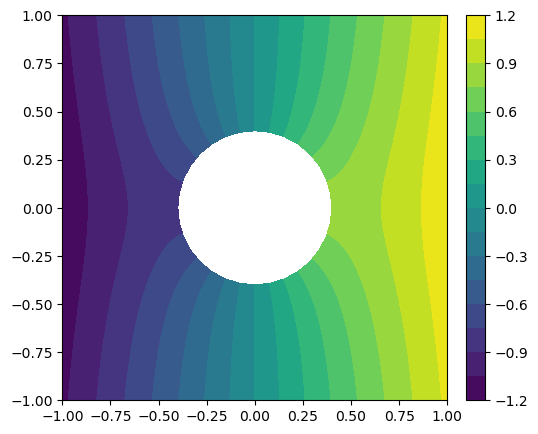

In [5]:
px, py = m.points[:, 0], m.points[:, 1]
print("max error at the vertices:", np.max(np.abs(uh.at(px, py) - exact(px, py))))

e = uh - uex
print("L2 error:", np.sqrt(fd.form(e**2 * dx).assemble()))
print("H1 error:", np.sqrt(fd.form(dot(grad(e), grad(e)) * dx).assemble()))

fig, ax = plt.subplots(figsize=(6, 5))
uh.plot(ax, contour=True, levels=20)                  # contour lines of u_h
ax.set_aspect("equal")
plt.show()